In [1]:
import numpy as np
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import random

# Set the working directory to the project root directly
# Since this notebook is in scripts/, go to the parent directory
project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

import scripts.data_conversion as dc

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


### Hyperparameter tuning / training analysis

(60.2, 60.4)

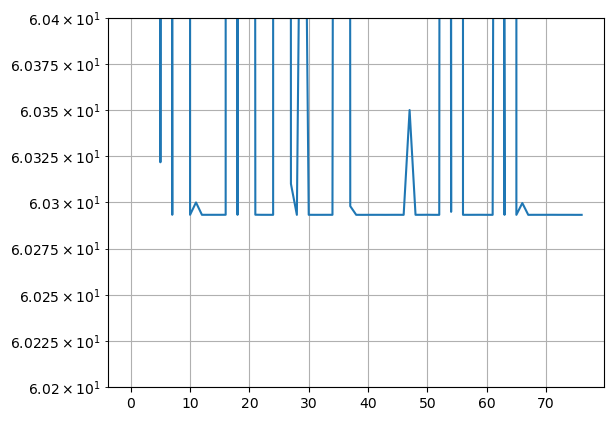

In [13]:
bs = 4
train_hist = np.load(f'models/PINN_ext_bootstrap_{bs}/training_history.npy')
plt.plot(train_hist)
plt.yscale('log')
plt.grid(axis='both',which='both')
# plt.ylim([train_hist[0],6.02933*1e1])
plt.ylim([60.2,60.4])

### Calculator

In [23]:
input = torch.load('data/position_mso.pt')
print(f'input mean = {torch.mean(input)}, std = {torch.std(input)}')
alt = torch.load('data/position_pc.pt')[:,0]
alt = alt.unsqueeze(1)
print(f'Alt mean = {torch.mean(alt)}, std = {torch.std(alt)}')
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(f'Target mean = {torch.mean(target)} std = {torch.std(target)}')

input mean = 6.006184101104736, std = 3967.865478515625
Alt mean = 3234.762451171875, std = 1828.796875
Target mean = 0.08023015409708023 std = 7.764457702636719


In [26]:
col = 2
print(f'input mean = {torch.mean(input[:,col])}, std = {torch.std(input[:,col])}')

input mean = 71.04672241210938, std = 4517.708984375


In [29]:
a = np.arange(10)
print(a)
print(a[:3])

[0 1 2 3 4 5 6 7 8 9]
[0 1 2]


In [ ]:
#weekly cost:
gaswerk = 11.20
# commute = 6.40*2
weekend_trip = 30#(30+60+50)/3
week_costs = gaswerk  + weekend_trip
year_costs = week_costs * 52.1 + 800
print("yearly costs (CHF): ", year_costs)

In [ ]:
print("Hello, World!")

### File conversion testing

In [31]:
input = torch.load('data/position_mso.pt')
alt = torch.load('data/position_pc.pt')[:,0]
xyz_mean = 6 # km
xyz_std = 3968 # km
alt_mean = 3235 # km
alt_std = 1829 # km
# Reshape alt to be a column vector to match input dimensions
x_norm = (input[:, :3] - xyz_mean) / xyz_std
alt_norm = (alt - alt_mean) / alt_std
x_norm = torch.cat([x_norm, alt_norm.unsqueeze(1)], dim=1)
print(x_norm)

tensor([[-0.2833, -1.1405,  0.5759, -0.7851],
        [-0.2830, -1.1399,  0.5764, -0.7859],
        [-0.2826, -1.1394,  0.5769, -0.7866],
        ...,
        [ 0.8592, -0.8642, -1.3870,  0.3809],
        [ 0.8596, -0.8640, -1.3867,  0.3807],
        [ 0.8600, -0.8638, -1.3865,  0.3804]])


In [16]:
print(torch.mean(alt))

tensor(3234.7625)


In [ ]:
# test position file
position = torch.load('data/position_pc.pt')
position_10000_random_picks = position[torch.randperm(position.size(0))[:10000]]
print(min(position_10000_random_picks[:, 0]), max(position_10000_random_picks[:, 0]))
print(min(position_10000_random_picks[:, 1]), max(position_10000_random_picks[:, 1]))
print(min(position_10000_random_picks[:, 2]), max(position_10000_random_picks[:, 2]))

In [ ]:
# compare crustal field from L19 and D25 (only scalar)
df = dc.format_sample()
df = df[['BL PC Bx','BL PC By','BL PC Bz']].values
crustal_field_pc = torch.load('data/crustal_field_pc.pt')
crustal_field_pc = crustal_field_pc[:len(df)]
df = torch.tensor(df, dtype=torch.float32)
B_l19 = np.sqrt(df[:,0]**2 + df[:,1]**2 + df[:,2]**2)
B_D25 = np.sqrt(crustal_field_pc[:,0]**2 + crustal_field_pc[:,1]**2 + crustal_field_pc[:,2]**2)
mse = torch.mean((B_l19 - B_D25)**2)
print("MSE crustal field (nT^2): ", mse.item())

In [ ]:
df = dc.format_sample()
df = df[['BL SS Bx','BL SS By','BL SS Bz']].values
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
crustal_field_mso = crustal_field_mso[:len(df)]
df = torch.tensor(df, dtype=torch.float32)

mse = torch.mean((crustal_field_mso-df)**2)
print("MSE crustal field (nT^2): ", mse.item())

### Curl tests

#### 2D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
X,Y = np.meshgrid(x0, y0)
x,y = X.ravel(), Y.ravel()
plt.figure()
plt.quiver(X,Y,Y,-X)
plt.show()


In [15]:
def tensor(t):
    return torch.tensor(t,dtype = torch.float32)


Input = torch.stack((tensor(x), tensor(y) ), dim=1)
Input = torch.tensor(Input,requires_grad=True)
Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1]
Output1[:,1] = -Input[:,0]
# gradient = torch.ones_like(Input)
Output1.sum().backward()
print(Input.grad.shape)

curl1 = Input.grad[:,0] - Input.grad[:,1]
print(torch.unique(curl1).item())

torch.Size([8000, 2])
-2.0


#### 3D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad=True

Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output1[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output1[:,2] = 0


Output1[:,0].sum().backward(retain_graph=True)
dBx_dx = Input.grad[:,0].clone()
dBx_dy = Input.grad[:,1].clone()
dBx_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,1].sum().backward(retain_graph=True)
dBy_dx = Input.grad[:,0].clone()
dBy_dy = Input.grad[:,1].clone()
dBy_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,2].sum().backward(retain_graph=True)
dBz_dx = Input.grad[:,0].clone()
dBz_dy = Input.grad[:,1].clone()
dBz_dz = Input.grad[:,2].clone()

curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
cond = curl[:,2] > 0
print(curl[:,2][cond])

analytical_curl = torch.zeros_like(Input)
analytical_curl[:,0] = 0
analytical_curl[:,1] = 0
analytical_curl[:,2] = 3*Input[:,0]**2 - 3*Input[:,1]**2

print(analytical_curl[:,2][cond])



#### 3D curl(curl()) in cartesian coordinates

In [ ]:
def curl(Input, Output):
    
    Output[:,0].sum().backward(retain_graph=True)
    dBx_dx = Input.grad[:,0].clone()
    dBx_dy = Input.grad[:,1].clone()
    dBx_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,1].sum().backward(retain_graph=True)
    dBy_dx = Input.grad[:,0].clone()
    dBy_dy = Input.grad[:,1].clone()
    dBy_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,2].sum().backward(retain_graph=True)
    dBz_dx = Input.grad[:,0].clone()
    dBz_dy = Input.grad[:,1].clone()
    dBz_dz = Input.grad[:,2].clone()

    curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
    return curl



x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad = True
Output = torch.zeros_like(Input)
Output[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output[:,2] = 0

curl1 = curl(Input, Output)

# checking results
tensors_combined = torch.concatenate((curl1,Input),dim=1)
tensors_combined = tensors_combined[cond].detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        
    elif (tensors_combined[i,2] == tensors_combined[i-1,2]):
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        




In [22]:
def curl_differentiable(Input, Output):
    """
    Compute curl while maintaining computational graph for higher-order derivatives
    """
    # Use torch.autograd.grad instead of .backward() to maintain graph
    
    # Compute all partial derivatives using the same logic as the working version
    # ∂Bx/∂(x,y,z)

    grad_Bx = torch.autograd.grad(Output[:,0].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBx_dx, dBx_dy, dBx_dz = grad_Bx[:,0], grad_Bx[:,1], grad_Bx[:,2]
    
    # ∂By/∂(x,y,z)  
    grad_By = torch.autograd.grad(Output[:,1].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBy_dx, dBy_dy, dBy_dz = grad_By[:,0], grad_By[:,1], grad_By[:,2]
    
    # ∂Bz/∂(x,y,z)
    grad_Bz = torch.autograd.grad(Output[:,2].sum(), Input, create_graph=True, retain_graph=True)[0] 
    dBz_dx, dBz_dy, dBz_dz = grad_Bz[:,0], grad_Bz[:,1], grad_Bz[:,2]
    
    # Curl formula: (∂Bz/∂y - ∂By/∂z, ∂Bx/∂z - ∂Bz/∂x, ∂By/∂x - ∂Bx/∂y)
    curl_x = dBz_dy - dBy_dz
    curl_y = dBx_dz - dBz_dx  
    curl_z = dBy_dx - dBx_dy
    
    return torch.stack((curl_x, curl_y, curl_z), dim=1)

# Test and compare both versions
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input_new = torch.stack((tensor(x), tensor(y), tensor(z)), dim=1)
Input_new.requires_grad_(True)

Output_new = torch.zeros_like(Input_new)
Output_new[:,0] = Input_new[:,1] ** 3 - 9* Input_new[:,1]
Output_new[:,1] = Input_new[:,0] ** 3 - 9* Input_new[:,0]  
Output_new[:,2] = 0

print("Computing curl with differentiable version...")
curl1_diff = curl_differentiable(Input_new, Output_new)
# check_result(curl1_diff, Input_new)

curl2_diff = curl_differentiable(Input_new, curl1_diff)







tensors_combined = torch.concatenate((curl2_diff,Input),dim=1)
tensors_combined = tensors_combined.detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
    elif (tensors_combined[i,0:2] == tensors_combined[i-1,0:2]).all():
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')


Computing curl with differentiable version...
8000
[ 60.  60.   0. -10. -10.]
Analytical solution : x = 60.0, y = 60.0
[ 60.  54.   0.  -9. -10.]
Analytical solution : x = 60.0, y = 54.0
[ 60.  48.   0.  -8. -10.]
Analytical solution : x = 60.0, y = 48.0
[ 60.  42.   0.  -7. -10.]
Analytical solution : x = 60.0, y = 42.0
[ 60.  36.   0.  -6. -10.]
Analytical solution : x = 60.0, y = 36.0
[ 60.  30.   0.  -5. -10.]
Analytical solution : x = 60.0, y = 30.0
[ 60.  24.   0.  -4. -10.]
Analytical solution : x = 60.0, y = 24.0
[ 60.  18.   0.  -3. -10.]
Analytical solution : x = 60.0, y = 18.0
[ 60.  12.   0.  -2. -10.]
Analytical solution : x = 60.0, y = 12.0
[ 60.   6.   0.  -1. -10.]
Analytical solution : x = 60.0, y = 6.0
[ 60.   0.   0.   0. -10.]
Analytical solution : x = 60.0, y = -0.0
[ 60.  -6.   0.   1. -10.]
Analytical solution : x = 60.0, y = -6.0
[ 60. -12.   0.   2. -10.]
Analytical solution : x = 60.0, y = -12.0
[ 60. -18.   0.   3. -10.]
Analytical solution : x = 60.0, y = -1